In [1]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 39.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
!pip install ultralytics opencv-python matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ultralytics]


In [3]:
"""
Fine-tuning YOLO26n on a Fire/Smoke Dataset — Kaggle Dual T4 GPU
================================================================
Run it as a single cell or multiple cells in a Kaggle Notebook.
"""

# ============================================================
# Step 0: Installation (separate cell, run only once)
# ============================================================
# !pip install ultralytics --upgrade -q

# ============================================================
# Step 1: Check Available GPUs
# ============================================================
import torch
print(f"Number of available GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

# ============================================================
# Step 2: Build the data.yaml File
# ============================================================
# Why do we need this step:
# Ultralytics requires a YAML file describing the train/val/test
# paths and the class names. The dataset paths are configured
# exactly according to the provided dataset structure.

import yaml

data_yaml_content = {
    "path": "/kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset",
    "train": "train/images",
    "val": "val/images",   # Change if the structure is different inside val
    "test": "test/images", # Same note for test
    "names": {
        0: "fire",
        1: "smoke"
    }
}

# If val and test do not contain an "images" subfolder
# (i.e., images are directly inside val/test), change the values
# above to "val" and "test".
# Check the actual directory structure first using this cell:
import os
base = "/kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset"
for split in ["train", "val", "test"]:
    p = os.path.join(base, split)
    if os.path.exists(p):
        print(f"{split}: {os.listdir(p)}")

data_yaml_path = "/kaggle/working/fire_smoke_data.yaml"
with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

print(f"\nCreated: {data_yaml_path}")
print(open(data_yaml_path).read())

# ============================================================
# Step 3: Training — Dual GPU + Checkpoints + Shuffle
# ============================================================
from ultralytics import YOLO

# Load the pretrained base model (pretrained on COCO)
model = YOLO("yolo26n.pt")   # Nano version — suitable for realtime CPU inference later

results = model.train(
    data=data_yaml_path,

    # ---- Basics ----
    epochs=200,          # Maximum number of epochs; training may stop earlier due to patience
    patience=20,         # Stop if mAP does not improve for 20 consecutive epochs
    imgsz=640,           # Standard image size, sufficient for fire/smoke targets
    batch=32,            # If CUDA Out Of Memory occurs, reduce to 16 or 24

    # ---- Multi-GPU ----
    device=[0, 1],       # Uses both GPUs simultaneously through DistributedDataParallel

    # ---- Save checkpoints during training ----
    project="/kaggle/working/runs",  # Save inside /kaggle/working so it is available as output
    name="fire_smoke_yolo26n",
    exist_ok=True,
    save=True,            # Saves last.pt and best.pt during training
    save_period=5,        # Also saves numbered checkpoints every 5 epochs as additional backups

    # ---- Live training metrics ----
    plots=True,            # Automatically generates loss/mAP plots and saves them as PNG files
    verbose=True,          # Prints training details for each batch/epoch in the output

    # ---- Additional useful settings ----
    workers=4,             # Number of CPU workers used for loading the dataset
    seed=42,               # Makes results more reproducible when training again
    val=True,              # Runs validation after each epoch and reports mAP
)

print("\n\nTraining finished. Best model saved at:")
print(f"/kaggle/working/runs/fire_smoke_yolo26n/weights/best.pt")

Number of available GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
train: ['labels', 'images']
val: ['labels', 'images']
test: ['labels', 'images']

Created: /kaggle/working/fire_smoke_data.yaml
names:
  0: fire
  1: smoke
path: /kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset
test: test/images
train: train/images
val: val/images

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mos

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/200      2.95G      1.637        3.7    0.01991         26        640: 100% ━━━━━━━━━━━━ 145/145 3.4it/s 42.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.5it/s 4.2s
                   all       1155       1612      0.361      0.246      0.216     0.0821

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/200      2.95G      1.747      3.004    0.02279         18        640: 100% ━━━━━━━━━━━━ 145/145 3.5it/s 40.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.4it/s 4.4s
                   all       1155       1612      0.184      0.177      0.101     0.0328

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/200      2.95G      1.913      2.973    0.02551         17        640: 100% ━━━━━━━━━

In [4]:
"""
Resume Training — Corrected Version
===================================
The previous issue: resume=True relied on the args.yaml file next to the
checkpoint to recover the dataset path and previous settings. It failed
to find or correctly read that file, so it fell back to Ultralytics'
default settings (COCO128 demo dataset instead of your dataset). As a
result, training finished in 3 minutes on only 4 images and produced
classes such as person/dog/horse.

Solution: Load the trained weights only (not full resume), then explicitly
specify all training settings just like the original training run, with
a larger total number of epochs.
"""

from ultralytics import YOLO

# Check that the required files actually exist before continuing
import os
last_ckpt = "/kaggle/working/runs/fire_smoke_yolo26n/weights/last.pt"
data_yaml = "/kaggle/working/fire_smoke_data.yaml"

assert os.path.exists(last_ckpt), f"File not found: {last_ckpt} — check the path"
assert os.path.exists(data_yaml), f"File not found: {data_yaml} — check the path"

print(f"Loading weights from: {last_ckpt}")
print(f"Using dataset from: {data_yaml}")

# Load the trained weights (not resume — only use the weights as the starting point)
model = YOLO(last_ckpt)

results = model.train(
    data=data_yaml,          # Explicitly specify the dataset path
    epochs=180,              # Technically starts from epoch 0, but uses your trained weights
    patience=25,
    imgsz=640,
    batch=32,
    device=[0, 1],
    project="/kaggle/working/runs",
    name="fire_smoke_yolo26n_continued",   # Different name to avoid overwriting the original run
    exist_ok=True,
    save=True,
    save_period=5,
    plots=True,
    verbose=True,
    workers=4,
    seed=42,
    val=True,
)

print("\nTraining finished. New result:")
print("/kaggle/working/runs/fire_smoke_yolo26n_continued/weights/best.pt")

Loading weights from: /kaggle/working/runs/fire_smoke_yolo26n/weights/last.pt
Using dataset from: /kaggle/working/fire_smoke_data.yaml
Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fire_smoke_data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=180, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/180      2.95G       1.18     0.8248    0.01276         26        640: 100% ━━━━━━━━━━━━ 145/145 3.2it/s 45.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.4it/s 4.3s
                   all       1155       1612      0.708      0.593       0.63      0.335

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/180      2.95G      1.277      1.006    0.01496         18        640: 100% ━━━━━━━━━━━━ 145/145 3.3it/s 43.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.5it/s 4.2s
                   all       1155       1612      0.656      0.499      0.541      0.269

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/180      2.95G      1.427       1.21    0.01682         17        640: 100% ━━━━━━━━━

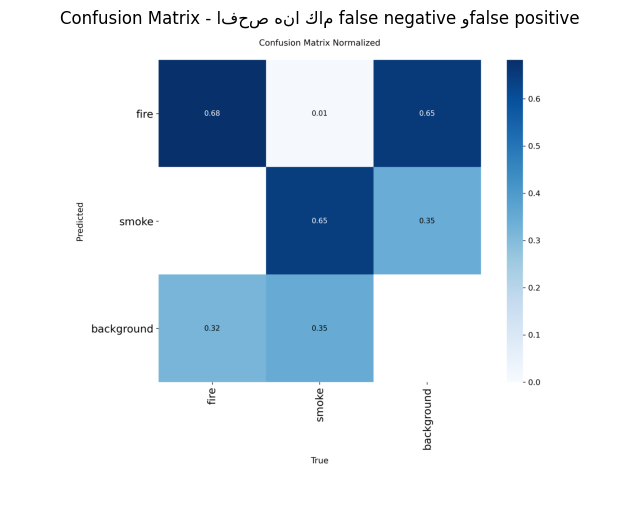

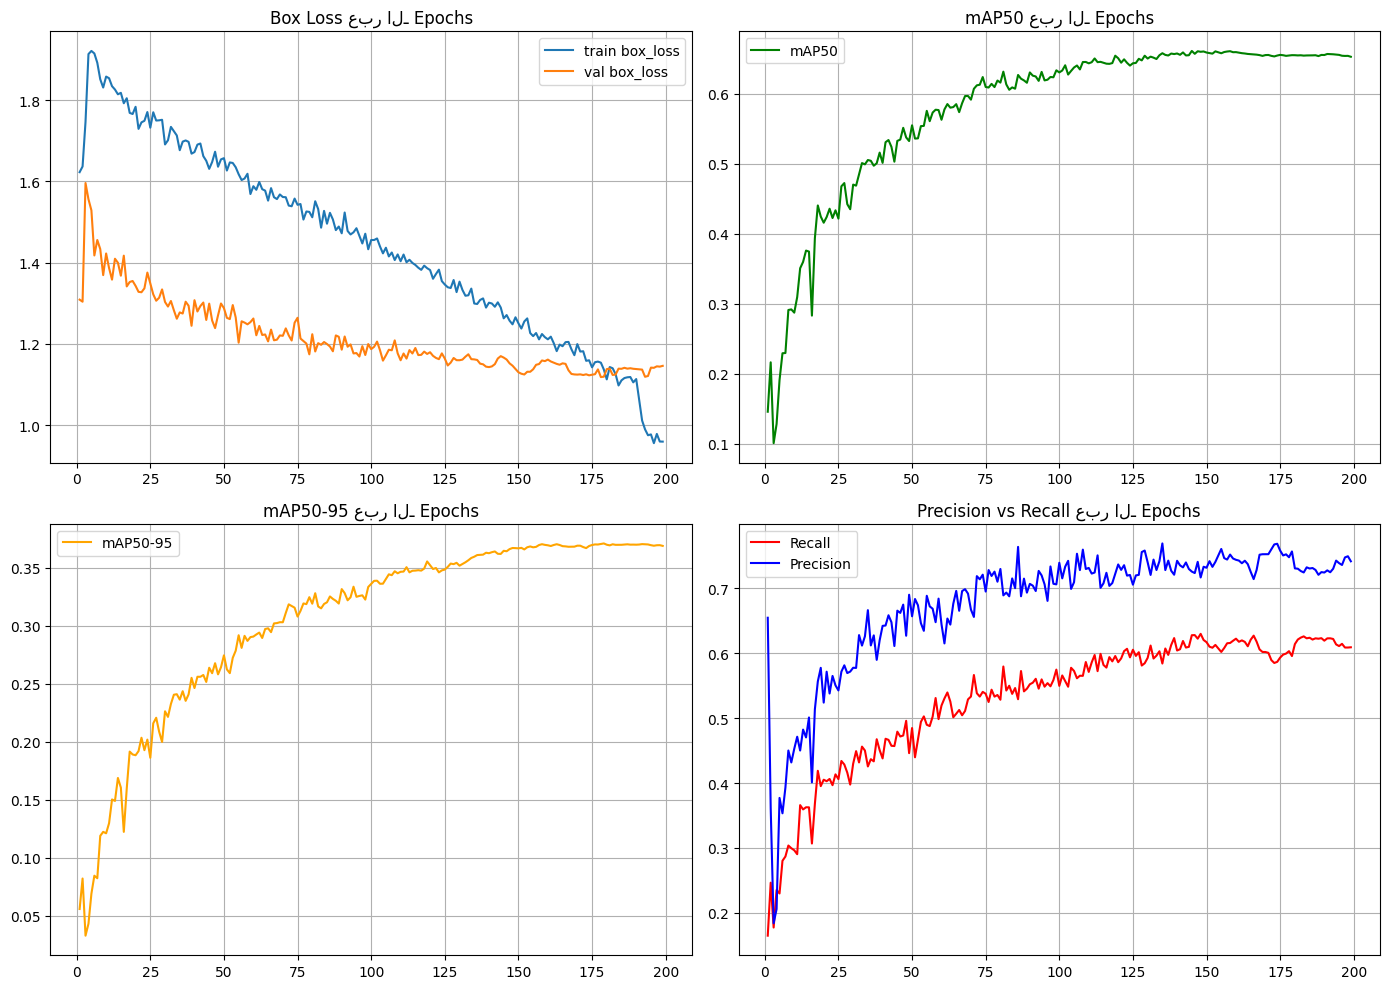


--- تحليل مهم ---
أقل val/box_loss: 1.1181 في epoch 178
أعلى mAP50 وصلنالها: 0.6609 في epoch 145
لو الـ val/box_loss بدأ يزيد بعد نقطة معينة بينما train/box_loss فاضل ينزل → ده overfitting
لو الاتنين واقفين مع بعض من إمبارح → ده plateau حقيقي، مش هينفع زيادة epochs

image 1/1 /kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset/val/images/ds2_small_-233-_jpg.rf.982ab78bb83f20963f1993344e13f7ef.jpg: 640x640 1 fire, 9.7ms
Speed: 28.5ms preprocess, 9.7ms inference, 24.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/prediction_samples/samples

image 1/1 /kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset/val/images/ds2_large_-1685-_jpg.rf.49d114f0593e9a21044e0dacb2598508_gray.jpg: 640x640 1 fire, 10.9ms
Speed: 2.9ms preprocess, 10.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/prediction_samples/samples

image 1/1 /kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_

In [5]:
"""
تشخيص نتائج التدريب — الخطوة الأولى قبل أي قرار (زيادة epochs، تغيير موديل، إلخ)
================================================================================
شغّل الكود ده في Kaggle بعد التدريب مباشرة.
"""

from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import os

# ============================================================
# 1. شوف الـ confusion matrix (اتحفظت أوتوماتيك أثناء التدريب)
# ============================================================
# ده بيوريك بالظبط: كام مرة الموديل قال "fire" وكان صح،
# كام مرة قال "fire" وكان غلط (false positive)،
# كام مرة فوّت نار حقيقية (false negative)
cm_path = "/kaggle/working/runs/fire_smoke_yolo26n/confusion_matrix_normalized.png"
if os.path.exists(cm_path):
    img = Image.open(cm_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix - افحص هنا كام false negative وfalse positive")
    plt.show()
else:
    print(f"الملف مش موجود في {cm_path}، دور عليه في مجلد الـ run")

# ============================================================
# 2. شوف منحنيات الـ Loss/mAP كاملة (مش بس آخر 3 epochs)
# ============================================================
results_csv = "/kaggle/working/runs/fire_smoke_yolo26n/results.csv"
if os.path.exists(results_csv):
    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='train box_loss')
    axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='val box_loss')
    axes[0, 0].set_title('Box Loss عبر الـ Epochs')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
    axes[0, 1].set_title('mAP50 عبر الـ Epochs')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='orange')
    axes[1, 0].set_title('mAP50-95 عبر الـ Epochs')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='red')
    axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue')
    axes[1, 1].set_title('Precision vs Recall عبر الـ Epochs')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/full_training_curves.png")
    plt.show()

    print("\n--- تحليل مهم ---")
    print(f"أقل val/box_loss: {df['val/box_loss'].min():.4f} في epoch {df['val/box_loss'].idxmin()+1}")
    print(f"أعلى mAP50 وصلنالها: {df['metrics/mAP50(B)'].max():.4f} في epoch {df['metrics/mAP50(B)'].idxmax()+1}")
    print("لو الـ val/box_loss بدأ يزيد بعد نقطة معينة بينما train/box_loss فاضل ينزل → ده overfitting")
    print("لو الاتنين واقفين مع بعض من إمبارح → ده plateau حقيقي، مش هينفع زيادة epochs")
else:
    print(f"الملف مش موجود: {results_csv}")

# ============================================================
# 3. جرب الموديل على عينة من صور الـ val وشوف الأخطاء بعينك
# ============================================================
model = YOLO("/kaggle/working/runs/fire_smoke_yolo26n/weights/best.pt")

val_images_dir = "/kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset/val/images"
sample_images = os.listdir(val_images_dir)[:20]  # أول 20 صورة كعينة

os.makedirs("/kaggle/working/prediction_samples", exist_ok=True)

for img_name in sample_images:
    img_path = os.path.join(val_images_dir, img_name)
    results = model.predict(img_path, conf=0.25, save=True,
                             project="/kaggle/working/prediction_samples",
                             name="samples", exist_ok=True)

print("\nالنتائج المرسومة (boxes) محفوظة في:")
print("/kaggle/working/prediction_samples/samples/")
print("افتحها وشوف بعينك: هل بيكتشف نار حقيقية؟ هل بيديله false positive على حاجات حمرا مش نار؟")

# Without Low Res

In [6]:
"""
Fine-tuning YOLO26n on a Fire/Smoke Dataset — Kaggle Dual T4 GPU
================================================================
Run it as a single cell or multiple cells in a Kaggle Notebook.
"""

# ============================================================
# Step 0: Installation (separate cell, run only once)
# ============================================================
# !pip install ultralytics --upgrade -q

# ============================================================
# Step 1: Check Available GPUs
# ============================================================
import torch
print(f"Number of available GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

# ============================================================
# Step 2: Build the data.yaml File
# ============================================================
# Why do we need this step:
# Ultralytics requires a YAML file describing the train/val/test
# paths and the class names. The dataset paths are configured
# exactly according to the provided dataset structure.

import yaml

data_yaml_content = {
    "path": "/kaggle/input/datasets/ramyahmed16/without-low/final_merged_dataset",
    "train": "train/images",
    "val": "val/images",   # Change if the structure is different inside val
    "names": {
        0: "fire",
        1: "smoke"
    }
}

# If val and test do not contain an "images" subfolder
# (i.e., images are directly inside val/test), change the values
# above to "val" and "test".
# Check the actual directory structure first using this cell:
import os
base = "/kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset"
for split in ["train", "val", "test"]:
    p = os.path.join(base, split)
    if os.path.exists(p):
        print(f"{split}: {os.listdir(p)}")

data_yaml_path = "/kaggle/working/fire_smoke_data.yaml"
with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

print(f"\nCreated: {data_yaml_path}")
print(open(data_yaml_path).read())

# ============================================================
# Step 3: Training — Dual GPU + Checkpoints + Shuffle
# ============================================================
from ultralytics import YOLO

# Load the pretrained base model (pretrained on COCO)
model = YOLO("yolo26n.pt")   # Nano version — suitable for realtime CPU inference later

results = model.train(
    data=data_yaml_path,

    # ---- Basics ----
    epochs=200,          # Maximum number of epochs; training may stop earlier due to patience
    patience=20,         # Stop if mAP does not improve for 20 consecutive epochs
    imgsz=640,           # Standard image size, sufficient for fire/smoke targets
    batch=32,            # If CUDA Out Of Memory occurs, reduce to 16 or 24

    # ---- Multi-GPU ----
    device=[0, 1],       # Uses both GPUs simultaneously through DistributedDataParallel

    # ---- Save checkpoints during training ----
    project="/kaggle/working/runs",  # Save inside /kaggle/working so it is available as output
    name="fire_smoke_yolo26n",
    exist_ok=True,
    save=True,            # Saves last.pt and best.pt during training
    save_period=5,        # Also saves numbered checkpoints every 5 epochs as additional backups

    # ---- Live training metrics ----
    plots=True,            # Automatically generates loss/mAP plots and saves them as PNG files
    verbose=True,          # Prints training details for each batch/epoch in the output

    # ---- Additional useful settings ----
    workers=4,             # Number of CPU workers used for loading the dataset
    seed=42,               # Makes results more reproducible when training again
    val=True,              # Runs validation after each epoch and reports mAP
)

print("\n\nTraining finished. Best model saved at:")
print(f"/kaggle/working/runs/fire_smoke_yolo26n/weights/best.pt")

Number of available GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
train: ['labels', 'images']
val: ['labels', 'images']
test: ['labels', 'images']

Created: /kaggle/working/fire_smoke_data.yaml
names:
  0: fire
  1: smoke
path: /kaggle/input/datasets/ramyahmed16/without-low/final_merged_dataset
train: train/images
val: val/images

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fire_smoke_data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropou

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/200      2.97G      1.583      3.129    0.01868         20        640: 100% ━━━━━━━━━━━━ 194/194 3.1it/s 1:02
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.9it/s 2.8s
                   all        672        737       0.36      0.188      0.196     0.0788

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/200      2.97G      1.691      2.443    0.02084         19        640: 100% ━━━━━━━━━━━━ 194/194 3.3it/s 59.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 4.3it/s 2.6s
                   all        672        737      0.618      0.122      0.106     0.0345

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/200      2.97G       1.85      2.419    0.02396         16        640: 100% ━━━━━━━━━━

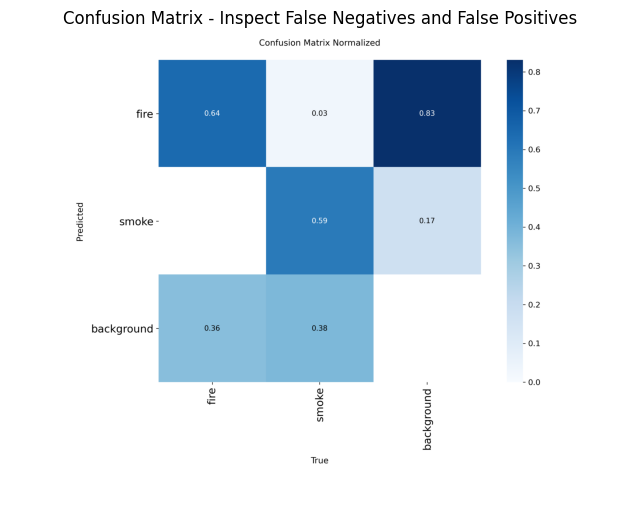

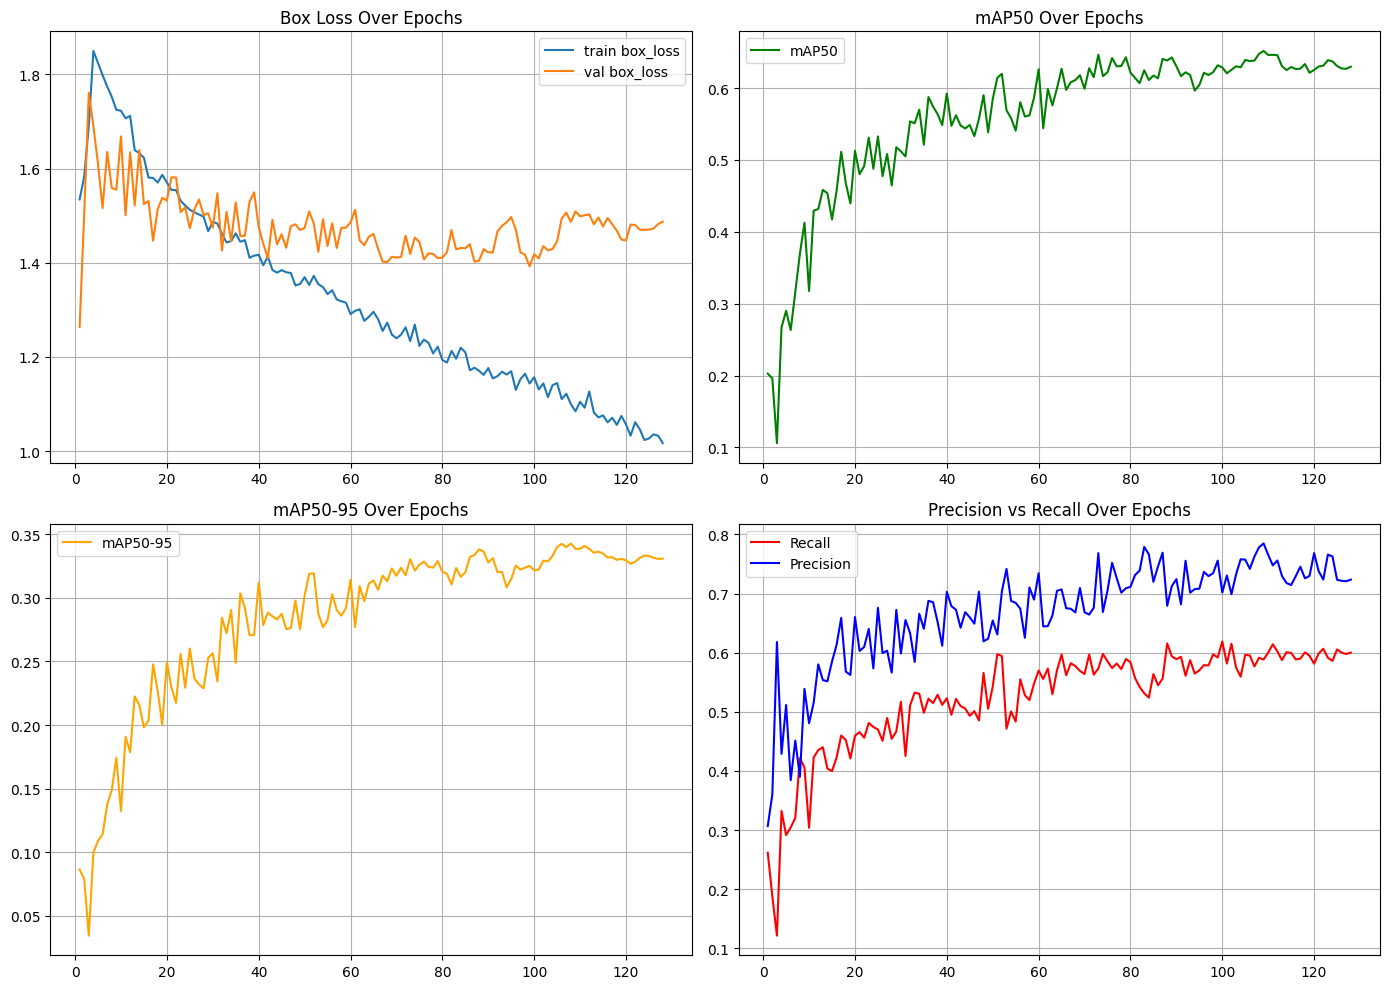


--- Diagnostic Analysis ---
Lowest val/box_loss: 1.2634 at epoch 1
Highest mAP50 reached: 0.6518 at epoch 109
If val/box_loss increases after a certain epoch while train/box_loss keeps decreasing → Overfitting.
If both losses hit a plateau and stop improving → Increasing epochs won't help further.

image 1/1 /kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset/val/images/ds2_small_-233-_jpg.rf.982ab78bb83f20963f1993344e13f7ef.jpg: 640x640 (no detections), 8.9ms
Speed: 2.0ms preprocess, 8.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/prediction_samples/samples

image 1/1 /kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset/val/images/ds2_large_-1685-_jpg.rf.49d114f0593e9a21044e0dacb2598508_gray.jpg: 640x640 1 fire, 11.9ms
Speed: 2.5ms preprocess, 11.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/prediction_samples/samples

image 1/1 /kaggle/input/data

In [7]:
"""
Training Diagnostics — First Step Before Any Decision (Increasing Epochs, Changing Model, etc.)
================================================================================================
Run this code in Kaggle directly after training completes.
"""

import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# ============================================================
# 1. View Confusion Matrix (Saved automatically during training)
# ============================================================
# This shows exactly:
# - How many times the model predicted "fire" correctly
# - How many false positives (predicted "fire" incorrectly)
# - How many false negatives (missed actual fire/smoke)
cm_path = "/kaggle/working/runs/fire_smoke_yolo26n/confusion_matrix_normalized.png"
if os.path.exists(cm_path):
    img = Image.open(cm_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix - Inspect False Negatives and False Positives")
    plt.show()
else:
    print(f"File not found at {cm_path}. Check inside the run folder.")

# ============================================================
# 2. Plot Full Loss/mAP Curves (Beyond just the last few epochs)
# ============================================================
results_csv = "/kaggle/working/runs/fire_smoke_yolo26n/results.csv"
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='train box_loss')
    axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='val box_loss')
    axes[0, 0].set_title('Box Loss Over Epochs')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
    axes[0, 1].set_title('mAP50 Over Epochs')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='orange')
    axes[1, 0].set_title('mAP50-95 Over Epochs')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='red')
    axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue')
    axes[1, 1].set_title('Precision vs Recall Over Epochs')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/full_training_curves.png")
    plt.show()

    print("\n--- Diagnostic Analysis ---")
    print(f"Lowest val/box_loss: {df['val/box_loss'].min():.4f} at epoch {df['val/box_loss'].idxmin()+1}")
    print(f"Highest mAP50 reached: {df['metrics/mAP50(B)'].max():.4f} at epoch {df['metrics/mAP50(B)'].idxmax()+1}")
    print("If val/box_loss increases after a certain epoch while train/box_loss keeps decreasing → Overfitting.")
    print("If both losses hit a plateau and stop improving → Increasing epochs won't help further.")
else:
    print(f"File not found: {results_csv}")

# ============================================================
# 3. Test Model on a Sample of Validation Images for Visual Inspection
# ============================================================
model = YOLO("/kaggle/working/runs/fire_smoke_yolo26n/weights/best.pt")

val_images_dir = "/kaggle/input/datasets/ramyahmed16/fire-smoke/Merged_Fire_Dataset/val/images"
sample_images = os.listdir(val_images_dir)[:20]  # Take the first 20 images as a sample

os.makedirs("/kaggle/working/prediction_samples", exist_ok=True)

for img_name in sample_images:
    img_path = os.path.join(val_images_dir, img_name)
    results = model.predict(
        img_path,
        conf=0.25,
        save=True,
        project="/kaggle/working/prediction_samples",
        name="samples",
        exist_ok=True
    )

print("\nRendered bounding box predictions saved to:")
print("/kaggle/working/prediction_samples/samples/")
print("Inspect the output images: Does it detect real fire/smoke correctly? Are there false positives on non-fire red objects?")